# BoardingPassOCR

In [ ]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 44.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="9irNYTmFGZEgJuwCdHqa")
project = rf.workspace("antonias-workspace-rv9y9").project("boarding-pass-info-detection-fq8oj")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to boarding-pass-info-detection-1 in yolov8:: 100%|██████████| 676/676 [00:00<00:00, 2453.68it/s]


In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.8 MB/s eta 0:00:00



[INFO] Dataset downloaded in: /content/boarding-pass-info-detection-1
[INFO] Classes detected: ['DXYZ4154_PNG_jpg.rf.c78a110d4cd3d90f18ec4f143e3a3987.txt']


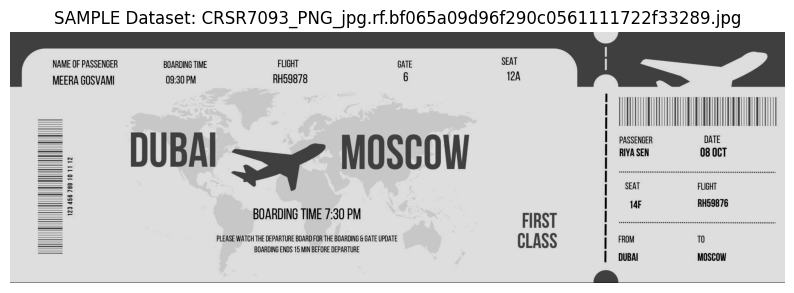

In [ ]:
from roboflow import Roboflow
import cv2
import matplotlib.pyplot as plt
import os

print(f"\n[INFO] Dataset downloaded in: {dataset.location}")
print(f"[INFO] Classes detected: {os.listdir(os.path.join(dataset.location, 'train/labels'))[:1]}") # Doar un check rapid

sample_img_path = os.path.join(dataset.location, "train/images")
img_name = os.listdir(sample_img_path)[0]
img = cv2.imread(os.path.join(sample_img_path, img_name))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.title(f"SAMPLE Dataset: {img_name}")
plt.axis('off')
plt.show()

In [ ]:
import os

train_images_path = os.path.join(dataset.location, "train", "images")
valid_images_path = os.path.join(dataset.location, "valid", "images")
test_images_path = os.path.join(dataset.location, "test", "images")

num_train_images = len(os.listdir(train_images_path)) if os.path.exists(train_images_path) else 0
num_valid_images = len(os.listdir(valid_images_path)) if os.path.exists(valid_images_path) else 0
num_test_images = len(os.listdir(test_images_path)) if os.path.exists(test_images_path) else 0

print(f"Number of training images: {num_train_images}")
print(f"Number of validation images: {num_valid_images}")
print(f"Number of test images: {num_test_images}")
print(f"Total images: {num_train_images + num_valid_images + num_test_images}")

Number of training images: 290
Number of validation images: 28
Number of test images: 14
Total images: 332


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    plots=True
)

print("\n[SUCCESS] TRAING FINISHED. Check 'runs/detect/train' for results.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/boarding-pass-info-detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_

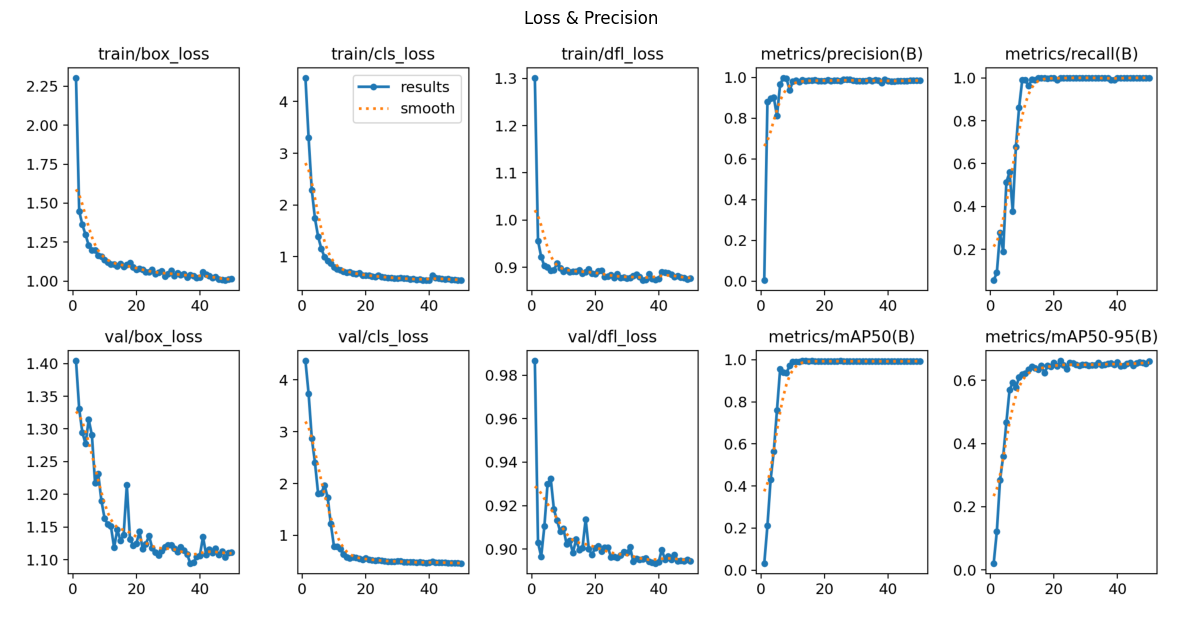

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

results_img_path = 'runs/detect/train/results.png'

if os.path.exists(results_img_path):
    img = mpimg.imread(results_img_path)
    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Loss & Precision")
    plt.show()
else:
    print("ERROR")

In [ ]:
# from ultralytics import YOLO

# model = YOLO('runs/detect/train/weights/best.pt')
# model.export(format='edgetpu')

# NGROK

In [ ]:
!pip install pyngrok flask ultralytics easyocr opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 23.2 MB/s eta 0:00:00


In [ ]:
'''import os
import cv2
import easyocr
from flask import Flask, request, jsonify
from pyngrok import ngrok
from ultralytics import YOLO

cale_model = 'runs/detect/train/weights/best.pt'
print(f"Model: {cale_model}")
model = YOLO(cale_model)

# EasyOCR
print("OCR...")
reader = easyocr.Reader(['en'])

# server web
app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    if 'image' not in request.files:
        return jsonify({"error": "NO PHOTO"}), 400

    file = request.files['image']
    filepath = "temp_bilet.jpg"
    file.save(filepath)

    # procesăm
    rezultate = model(filepath)[0]
    img = cv2.imread(filepath)
    date_extrase = {}

    for box in rezultate.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        nume_clasa = model.names[int(box.cls[0])]
        crop_img = img[y1:y2, x1:x2]

        text_citit = reader.readtext(crop_img, detail=0)
        if text_citit:
            date_extrase[nume_clasa] = " ".join(text_citit).strip()

    return jsonify({
        "status": "success",
        "data": date_extrase
    })
 # YOUR NGROK TOKEN AICI
TOKEN_NGROK = "TOKEN_NGROK"

ngrok.set_auth_token(TOKEN_NGROK)
ngrok.kill()
public_url = ngrok.connect(5000).public_url

print(f"\n API-UL TĂU ESTE LIVE LA: {public_url}/predict 🚀\n")

app.run(port=5000) '''

'import os\nimport cv2\nimport easyocr\nfrom flask import Flask, request, jsonify\nfrom pyngrok import ngrok\nfrom ultralytics import YOLO\n\ncale_model = \'runs/detect/train/weights/best.pt\'\nprint(f"Model: {cale_model}")\nmodel = YOLO(cale_model)\n\n# EasyOCR\nprint("OCR...")\nreader = easyocr.Reader([\'en\'])\n\n# server web\napp = Flask(__name__)\n\n@app.route(\'/predict\', methods=[\'POST\'])\ndef predict():\n    if \'image\' not in request.files:\n        return jsonify({"error": "NO PHOTO"}), 400\n\n    file = request.files[\'image\']\n    filepath = "temp_bilet.jpg"\n    file.save(filepath)\n\n    # procesăm\n    rezultate = model(filepath)[0]\n    img = cv2.imread(filepath)\n    date_extrase = {}\n\n    for box in rezultate.boxes:\n        x1, y1, x2, y2 = map(int, box.xyxy[0])\n        nume_clasa = model.names[int(box.cls[0])]\n        crop_img = img[y1:y2, x1:x2]\n\n        text_citit = reader.readtext(crop_img, detail=0)\n        if text_citit:\n            date_extrase[nu

# PredictionRegression

In [ ]:
! pip install pandas matplotlib seaborn

Loading data from dataset_airport_queue.csv...
Successfully loaded 96147 rows!
Saved '1_heatmap_corelatii.png'
Saved '2_scatter_coada.png'




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Saved '3_boxplot_international.png'
All plots have been successfully saved! Open the images and check the data logic.


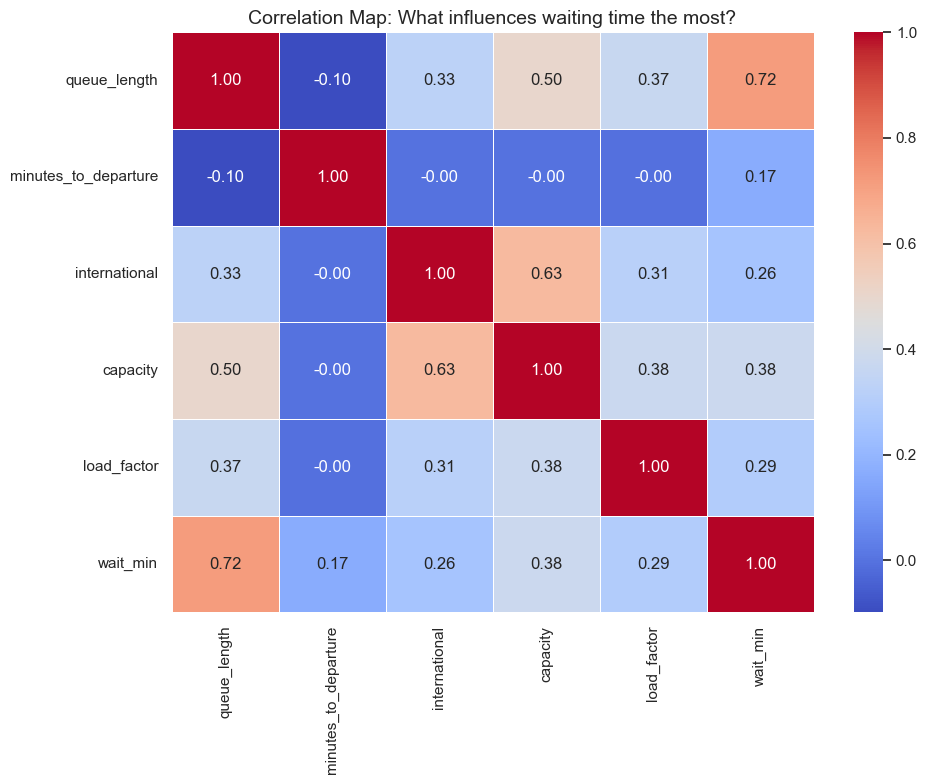

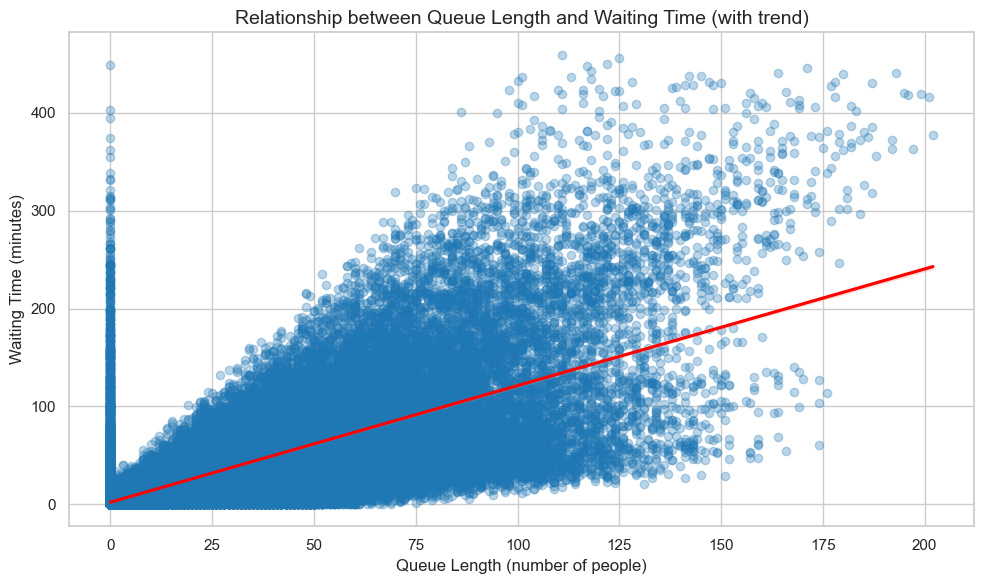

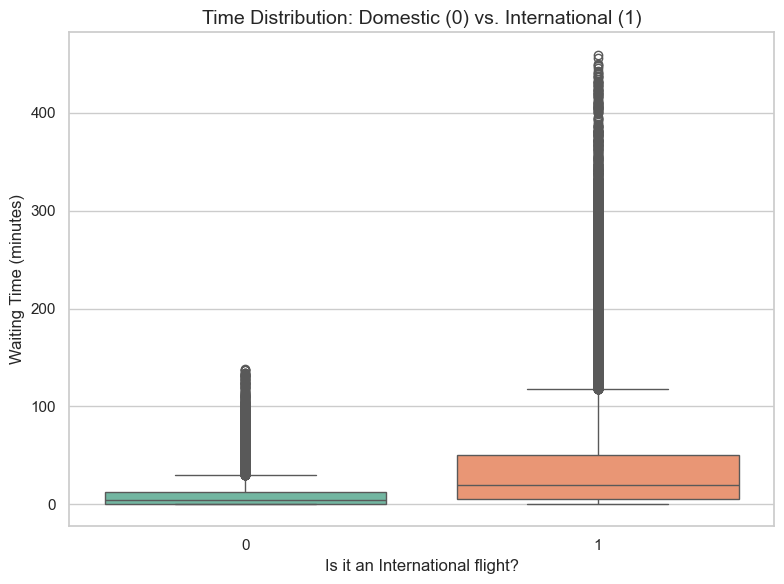

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

csv_file = 'dataset_airport_queue.csv'

print(f"Loading data from {csv_file}...")
df = pd.DataFrame()
try:
    df = pd.read_csv(csv_file)
    print(f"Successfully loaded {len(df)} rows!")
except FileNotFoundError:
    print(f"Could not find the file {csv_file}!")
    exit()

sns.set_theme(style="whitegrid")

# heatmap
plt.figure(figsize=(10, 8))
coloane_interes = ['queue_length', 'minutes_to_departure', 'international',
                   'capacity', 'load_factor', 'wait_min']
corelatii = df[coloane_interes].corr()

sns.heatmap(corelatii, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Map: What influences waiting time the most?', fontsize=14)
plt.tight_layout()
plt.savefig('1_heatmap_corelatii.png')
print("Saved '1_heatmap_corelatii.png'")

# QUEUE vs. WAITING TIME (SCATTER)
plt.figure(figsize=(10, 6))
# trend line (simple linear regression)
sns.regplot(data=df, x='queue_length', y='wait_min',
            scatter_kws={'alpha':0.3, 'color':'#1f77b4'},
            line_kws={'color':'red'})
plt.title('Relationship between Queue Length and Waiting Time (with trend)', fontsize=14)
plt.xlabel('Queue Length (number of people)')
plt.ylabel('Waiting Time (minutes)')
plt.tight_layout()
plt.savefig('2_scatter_coada.png')
print("Saved '2_scatter_coada.png'")

# DOMESTIC vs. INTERNATIONAL
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='international', y='wait_min', palette='Set2')
plt.title('Time Distribution: Domestic (0) vs. International (1)', fontsize=14)
plt.xlabel('Is it an International flight?')
plt.ylabel('Waiting Time (minutes)')
plt.tight_layout()
plt.savefig('3_boxplot_international.png')
print("Saved '3_boxplot_international.png'")

print("All plots have been successfully saved! Open the images and check the data logic.")

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

In [ ]:
print(f"Loaded {len(df)} rows.")

# mapping tipuri de cozi
df['stage_encoded'] = df['stage'].map({'checkin': 0, 'security': 1, 'boarding': 2})

# define features (inputs) and target (output)
feature_columns = [
    'queue_length',
    'minutes_to_departure',
    'international',
    'capacity',
    'load_factor',
    'day_of_week',    # adaugat pentru acuratete pe zile
    'stage_encoded'   # adaugat pentru a stii la ce coada sta
]

x = df[feature_columns]

# we want to predict the wait time
y = df['wait_min']

# split data: 80% for training, 20% for testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# train the random forest regressor
print("Training the random forest model...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

# test the model on the 20% unseen data
predictions = model.predict(x_test)

# calculate mean absolute error (how many minutes it gets wrong on average)
mae = mean_absolute_error(y_test, predictions)
# calculate r2 score (1.0 is perfect prediction)
r2 = r2_score(y_test, predictions)

print("\nModel evaluation:")
print(f"Average error: {mae:.2f} minutes")
print(f"R2 score: {r2:.2f}")

# save the model to a file so we can load it in the main api later
joblib.dump(model, 'wait_time_model.pkl')
print("\nModel saved as 'wait_time_model.pkl'")

Loaded 96147 rows.
Training the random forest model...

Model evaluation:
Average error: 6.72 minutes
R2 score: 0.96

Model saved as 'wait_time_model.pkl'


In [ ]:
!pip install flask pyngrok

STOP!!

In [ ]:
from flask import Flask, request, jsonify
from pyngrok import ngrok
import joblib

In [ ]:
'''import os
import cv2
import easyocr
import joblib
from flask import Flask, request, jsonify
from pyngrok import ngrok
from ultralytics import YOLO

# YOLO
cale_model = 'runs/detect/train/weights/best.pt'
print(f"Se încarcă YOLO de la: {cale_model}")
model_yolo = YOLO(cale_model)

# EasyOCR
print("Se încarcă EasyOCR...")
reader = easyocr.Reader(['en'])

# Random Forest
print("Se încarcă modelul Random Forest...")
model_rf = joblib.load('wait_time_model.pkl')

# INIȚIALIZARE SERVER WEB FLASK

app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    if 'image' not in request.files:
        return jsonify({"error": "NO PHOTO"}), 400

    file = request.files['image']
    filepath = "temp_bilet.jpg"
    file.save(filepath)

    # procesam cu YOLO
    rezultate = model_yolo(filepath)[0]
    img = cv2.imread(filepath)
    date_extrase = {}

    for box in rezultate.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        nume_clasa = model_yolo.names[int(box.cls[0])]
        crop_img = img[y1:y2, x1:x2]

        # citim cu EasyOCR
        text_citit = reader.readtext(crop_img, detail=0)
        if text_citit:
            date_extrase[nume_clasa] = " ".join(text_citit).strip()

    return jsonify({
        "status": "success",
        "data": date_extrase
    })

@app.route('/regresion', methods=['POST'])
def predict_wait_time():
    try:
        data = request.json

        # mapping
        mapping_stadii = {'checkin': 0, 'security': 1, 'boarding': 2}
        nume_stadiu = data.get('stage', 'checkin').lower()
        stadiu_numeric = mapping_stadii.get(nume_stadiu, 0)

        features = [[
            data['queue_length'],          # 1. queue_length
            data['minutes_to_departure'], # 2. minutes_to_departure
            data['international'],        # 3. international
            data['capacity'],             # 4. capacity
            data['load_factor'],          # 5. load_factor
            data['day_of_week'],          # 6. day_of_week
            stadiu_numeric                # 7. stage_encoded
        ]]

        prediction = model_rf.predict(features)[0]

        return jsonify({
            "status": "success",
            "estimated_wait_minutes": round(float(prediction), 1)
        })

    except Exception as e:
        return jsonify({
            "status": "error",
            "message": f"Eroare la procesarea datelor: {str(e)}"
        }), 400


TOKEN_NGROK = "NGROK_TOKEN"

ngrok.set_auth_token(TOKEN_NGROK)
ngrok.kill()
public_url = ngrok.connect(5000).public_url

print("="*50)
print(f"🚀 LIVE API!")
print(f"RUTA OCR (Bilete): {public_url}/predict")
print(f"RUTA ML (Timp):    {public_url}/regresion")

app.run(port=5000) '''

Se încarcă YOLO de la: runs/detect/train/weights/best.pt
Se încarcă EasyOCR...
Se încarcă modelul Random Forest...
🚀 LIVE API!
RUTA OCR (Bilete): https://thetic-jody-sandless.ngrok-free.dev/predict
RUTA ML (Timp):    https://thetic-jody-sandless.ngrok-free.dev/regresion
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


# STOCARE LOCALA

In [ ]:
from google.colab import drive
import shutil

drive.mount('/content/drive')

folder_drive = '/content/drive/MyDrive/BFlow_Models'
import os
os.makedirs(folder_drive, exist_ok=True)

shutil.copy('runs/detect/train/weights/best.pt', f'{folder_drive}/best.pt')
shutil.copy('wait_time_model.pkl', f'{folder_drive}/wait_time_model.pkl')

print("Modelele au fost salvate permanent în Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/train/weights/best.pt'

In [ ]:
import os
import cv2
import easyocr
import joblib
from flask import Flask, request, jsonify
from pyngrok import ngrok
from ultralytics import YOLO
from google.colab import drive

print("Se conectează la Google Drive...")
drive.mount('/content/drive')

FOLDER_MODELE = '/content/drive/MyDrive/BFlow_Models'

# YOLO
cale_model = f'{FOLDER_MODELE}/best.pt'
print(f"Se încarcă YOLO de la: {cale_model}")
model_yolo = YOLO(cale_model)

# EasyOCR
print("Se încarcă EasyOCR...")
reader = easyocr.Reader(['en'])

# Random Forest
cale_rf = f'{FOLDER_MODELE}/wait_time_model.pkl'
print(f"Se încarcă modelul Random Forest de la: {cale_rf}")
model_rf = joblib.load(cale_rf)

app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    if 'image' not in request.files:
        return jsonify({"error": "NO PHOTO"}), 400

    file = request.files['image']
    filepath = "temp_bilet.jpg"
    file.save(filepath)

    # procesam cu YOLO
    rezultate = model_yolo(filepath)[0]
    img = cv2.imread(filepath)
    date_extrase = {}

    for box in rezultate.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        nume_clasa = model_yolo.names[int(box.cls[0])]
        crop_img = img[y1:y2, x1:x2]

        # citim cu EasyOCR
        text_citit = reader.readtext(crop_img, detail=0)
        if text_citit:
            date_extrase[nume_clasa] = " ".join(text_citit).strip()

    return jsonify({
        "status": "success",
        "data": date_extrase
    })

@app.route('/regresion', methods=['POST'])
def predict_wait_time():
    try:
        data = request.json

        # mapping
        mapping_stadii = {'checkin': 0, 'security': 1, 'boarding': 2}
        nume_stadiu = data.get('stage', 'checkin').lower()
        stadiu_numeric = mapping_stadii.get(nume_stadiu, 0)

        features = [[
            data['queue_length'],          # 1. queue_length
            data['minutes_to_departure'], # 2. minutes_to_departure
            data['international'],        # 3. international
            data['capacity'],             # 4. capacity
            data['load_factor'],          # 5. load_factor
            data['day_of_week'],          # 6. day_of_week
            stadiu_numeric                # 7. stage_encoded
        ]]

        prediction = model_rf.predict(features)[0]

        return jsonify({
            "status": "success",
            "estimated_wait_minutes": round(float(prediction), 1)
        })

    except Exception as e:
        return jsonify({
            "status": "error",
            "message": f"Eroare la procesarea datelor: {str(e)}"
        }), 400

TOKEN_NGROK = "NGROK_TOKEN"

ngrok.set_auth_token(TOKEN_NGROK)
ngrok.kill()
public_url = ngrok.connect(5000).public_url

print("="*50)
print(f"🚀 LIVE API!")
print(f"RUTA OCR (Bilete): {public_url}/predict")
print(f"RUTA ML (Timp):    {public_url}/regresion")
print("="*50)

app.run(port=5000)

Se conectează la Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se încarcă YOLO de la: /content/drive/MyDrive/BFlow_Models/best.pt


Se încarcă EasyOCR...
Se încarcă modelul Random Forest de la: /content/drive/MyDrive/BFlow_Models/wait_time_model.pkl
🚀 LIVE API!
RUTA OCR (Bilete): https://thetic-jody-sandless.ngrok-free.dev/predict
RUTA ML (Timp):    https://thetic-jody-sandless.ngrok-free.dev/regresion
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit



image 1/1 /content/temp_bilet.jpg: 224x640 2 arrival_airports, 3 boarding_times, 1 class, 1 date, 2 departure_airports, 2 flight_numbers, 1 gate, 2 names, 1 seat_number, 74.5ms
Speed: 2.3ms preprocess, 74.5ms inference, 0.9ms postprocess per image at shape (1, 3, 224, 640)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
INFO:werkzeug:127.0.0.1 - - [08/Mar/2026 10:17:17] "POST /predict HTTP/1.1" 200 -
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
INFO:werkzeug:127.0.0.1 - - [08/Mar/2026 10:17:19] "POST /regresion HTTP/1.1" 200 -
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
INFO:werkzeug:127.0.0.1 - - [08/Mar/2026 10:17:40] "POST /regresion HTTP/1.1" 200 -
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Rando